## 1. Import and Load Data

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import contextily as ctx
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", message="Could not parse column 'reversed'")

DATA_RAW  = Path("../../data/raw")
DATA_PROC = Path("../../data/processed")
DATA_EXT  = Path("../../data/external")

## 2. Load Layers

In [2]:
tracts     = gpd.read_file(DATA_PROC / "svi_tracts.geojson")
stations   = gpd.read_file(DATA_PROC / "all_stations.geojson")
hydrants   = gpd.read_file(DATA_PROC / "Fire_Hydrants.geojson")
hospitals  = gpd.read_file(DATA_PROC / "hospitals.geojson")
la_county  = gpd.read_file(DATA_RAW  / "la_county.geojson")
roads      = gpd.read_file(DATA_EXT  / "escape_routes_roads.geojson")

# Reproject all to EPSG:3857 for basemap compatibility
CRS = "EPSG:3857"
tracts    = tracts.to_crs(CRS)
stations  = stations.to_crs(CRS)
hydrants  = hydrants.to_crs(CRS)
hospitals = hospitals.to_crs(CRS)
la_county = la_county.to_crs(CRS)
roads     = roads.to_crs(CRS)

## 3. Shape & schema

In [3]:
layers = {
    "tracts": tracts,
    "stations": stations,
    "hydrants": hydrants,
    "hospitals": hospitals,
    "roads": roads
}

for name, gdf in layers.items():
    print(f"{name:12s} | rows: {len(gdf):>6,} | cols: {len(gdf.columns):>3} | geom: {gdf.geom_type.unique()}")


tracts       | rows:  2,493 | cols: 152 | geom: <ArrowStringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str
stations     | rows:    412 | cols:   6 | geom: <ArrowStringArray>
['Point']
Length: 1, dtype: str
hydrants     | rows: 60,295 | cols:   3 | geom: <ArrowStringArray>
['Point']
Length: 1, dtype: str
hospitals    | rows:    165 | cols:   4 | geom: <ArrowStringArray>
['Point']
Length: 1, dtype: str
roads        | rows: 61,375 | cols:  19 | geom: <ArrowStringArray>
['LineString']
Length: 1, dtype: str


In [4]:
tracts.columns.tolist()

['tract',
 'e_totpop',
 'm_totpop',
 'e_hu',
 'm_hu',
 'e_hh',
 'm_hh',
 'e_pov_150',
 'm_pov_150',
 'e_unemp',
 'm_unemp',
 'e_hburd',
 'm_hburd',
 'e_nohsdp',
 'm_nohsdp',
 'e_uninsur',
 'm_uninsur',
 'e_age_65',
 'm_age_65',
 'e_age_17',
 'm_age_17',
 'e_disabl',
 'm_disabl',
 'e_sngpnt',
 'm_sngpnt',
 'e_limeng',
 'm_limeng',
 'e_minrty',
 'm_minrty',
 'e_munit',
 'm_munit',
 'e_mobile',
 'm_mobile',
 'e_crowd',
 'm_crowd',
 'e_noveh',
 'm_noveh',
 'e_groupq',
 'm_groupq',
 'ep_pov_150',
 'mp_pov_150',
 'ep_unemp',
 'mp_unemp',
 'ep_hburd',
 'mp_hburd',
 'ep_nohsdp',
 'mp_nohsdp',
 'ep_uninsur',
 'mp_uninsur',
 'ep_age_65',
 'mp_age_65',
 'ep_age_17',
 'mp_age_17',
 'ep_disabl',
 'mp_disabl',
 'ep_sngpnt',
 'mp_sngpnt',
 'ep_limeng',
 'mp_limeng',
 'ep_minrty',
 'mp_minrty',
 'ep_munit',
 'mp_munit',
 'ep_mobile',
 'mp_mobile',
 'ep_crowd',
 'mp_crowd',
 'ep_noveh',
 'mp_noveh',
 'ep_groupq',
 'mp_groupq',
 'epl_pov_150',
 'epl_unemp',
 'epl_hburd',
 'epl_nohsdp',
 'epl_uninsur',
 

## 4. SVI distribution

In [5]:
# These ep_ columns are confirmed present in your data
theme1 = ["ep_pov_150", "ep_unemp", "ep_hburd", "ep_nohsdp", "ep_uninsur"]
theme2 = ["ep_age_65", "ep_age_17", "ep_disabl", "ep_sngpnt"]
theme4 = ["ep_limeng", "ep_munit", "ep_mobile", "ep_crowd", "ep_noveh", "ep_groupq"]

# ep_minrty not in your columns — check what race cols you have
race_cols = [c for c in tracts.columns if "race" in c or "minrty" in c or "hisp" in c]
print("Race/minority cols:", race_cols)

all_ep = theme1 + theme2 + theme4
valid  = [c for c in all_ep if c in tracts.columns]

tracts["RPL_THEMES"] = (
    tracts[valid]
    .replace(-999, np.nan)
    .rank(pct=True)
    .mean(axis=1)
)
print(tracts["RPL_THEMES"].describe())

Race/minority cols: ['e_minrty', 'm_minrty', 'ep_minrty', 'mp_minrty', 'epl_minrty', 'f_minrty', 'e_hisp', 'm_hisp', 'e_otherrace', 'm_otherrace', 'ep_hisp', 'mp_hisp', 'ep_otherrace', 'mp_otherrace']
count    2493.000000
mean        0.498545
std         0.147689
min         0.045477
25%         0.383865
50%         0.504586
75%         0.615032
max         0.874049
Name: RPL_THEMES, dtype: float64


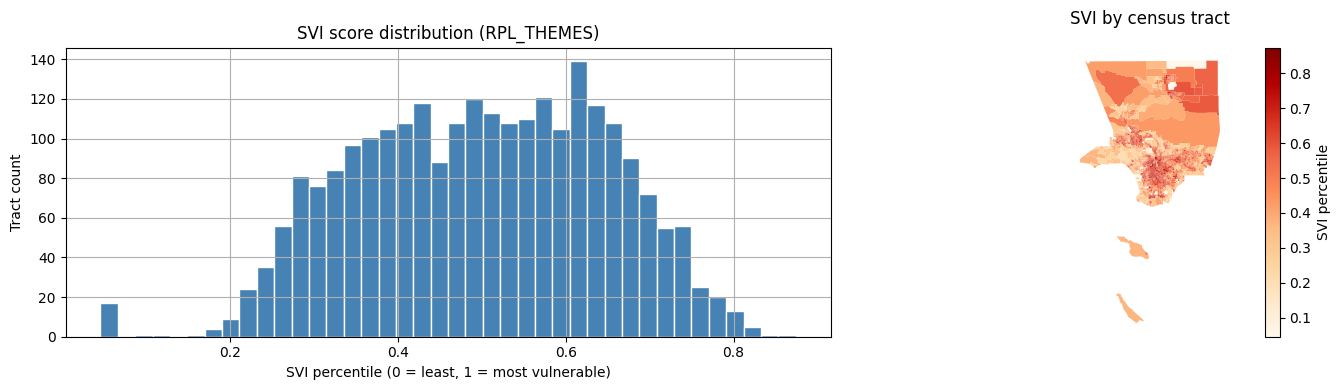

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
tracts["RPL_THEMES"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("SVI score distribution (RPL_THEMES)")
axes[0].set_xlabel("SVI percentile (0 = least, 1 = most vulnerable)")
axes[0].set_ylabel("Tract count")

# Choropleth
tracts.plot(column="RPL_THEMES", cmap="OrRd", legend=True,
            legend_kwds={"label": "SVI percentile"}, ax=axes[1])
axes[1].set_title("SVI by census tract")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. All layers on one map

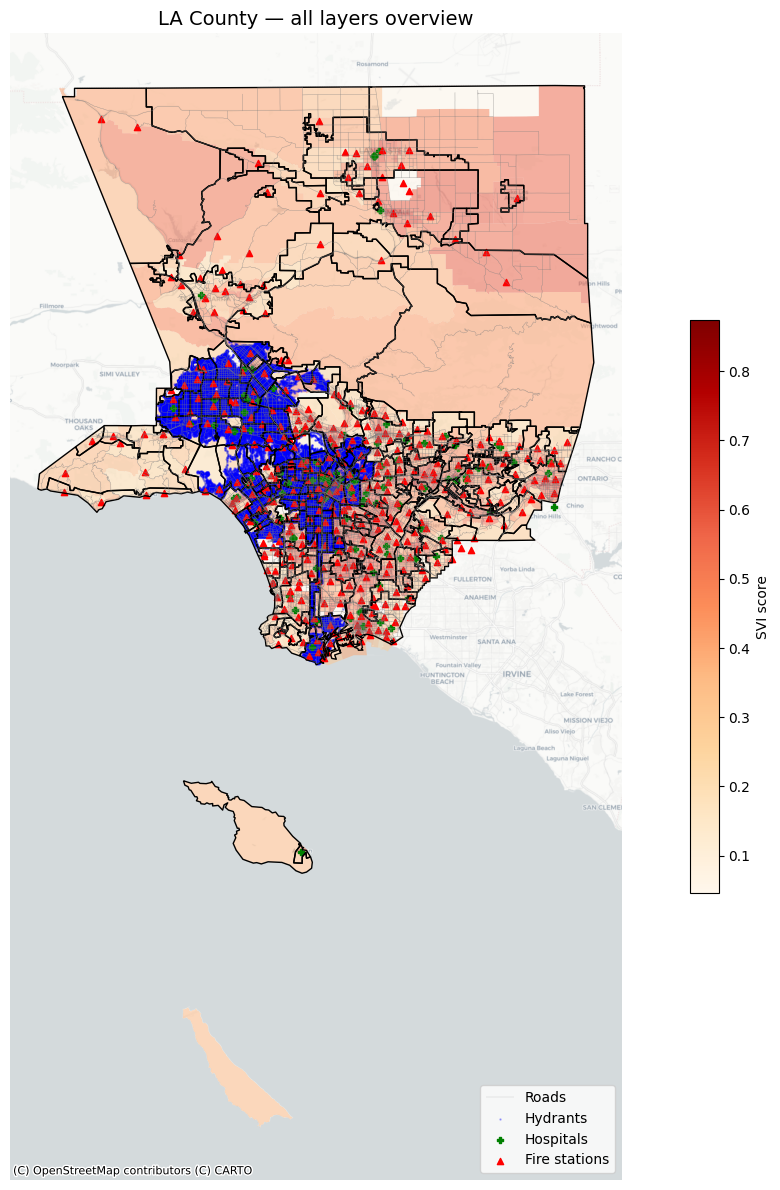

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))

la_county.boundary.plot(ax=ax, color="black", linewidth=1)
tracts.plot(ax=ax, column="RPL_THEMES", cmap="OrRd", alpha=0.5, legend=True,
            legend_kwds={"label": "SVI score", "shrink": 0.5})
roads.plot(ax=ax, color="gray", linewidth=0.3, alpha=0.4, label="Roads")
hydrants.plot(ax=ax, color="blue", markersize=0.5, alpha=0.3, label="Hydrants")
hospitals.plot(ax=ax, color="green", markersize=20, marker="P", label="Hospitals")
stations.plot(ax=ax, color="red", markersize=20, marker="^", label="Fire stations")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
ax.legend(loc="lower right")
ax.set_title("LA County — all layers overview", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Station & hydrant counts by type

In [8]:
print("=== Fire stations ===")
if "agency" in stations.columns:
    print(stations["agency"].value_counts())

print("\n=== Hospital types ===")
if "TYPE" in hospitals.columns:
    print(hospitals["TYPE"].value_counts())

print("\n=== Road types ===")
if "highway" in roads.columns:
    print(roads["highway"].value_counts().head(10))

=== Fire stations ===

=== Hospital types ===

=== Road types ===
highway
[tertiary]          19524
[secondary]         16756
[primary]           14102
[motorway_link]      3635
[motorway]           3127
[primary_link]       1519
[trunk]               990
[secondary_link]      968
[tertiary_link]       438
[trunk_link]          225
Name: count, dtype: int64


## 7. Missing value audit

In [9]:
print("=== Missing values per layer ===\n")
for name, gdf in layers.items():
    missing = gdf.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"--- {name} ---")
        print(missing)
        print()
    else:
        print(f"{name}: no missing values")

=== Missing values per layer ===

--- tracts ---
mp_pov_150      24
ep_unemp        22
mp_unemp        22
mp_hburd        24
ep_nohsdp       19
                ..
mp_nhpi         17
ep_twomore      17
mp_twomore      17
ep_otherrace    17
mp_otherrace    17
Length: 85, dtype: int64

--- stations ---
address    172
city        13
zip        172
stanum      22
dtype: int64

--- hydrants ---
hydrantid    2
dtype: int64

--- hospitals ---
city    2
dtype: int64

--- roads ---
lanes       13392
maxspeed    32062
name         7274
bridge      56548
ref         55238
access      60796
tunnel      61224
junction    60988
width       61122
service     61368
dtype: int64



## Spatial coverage check

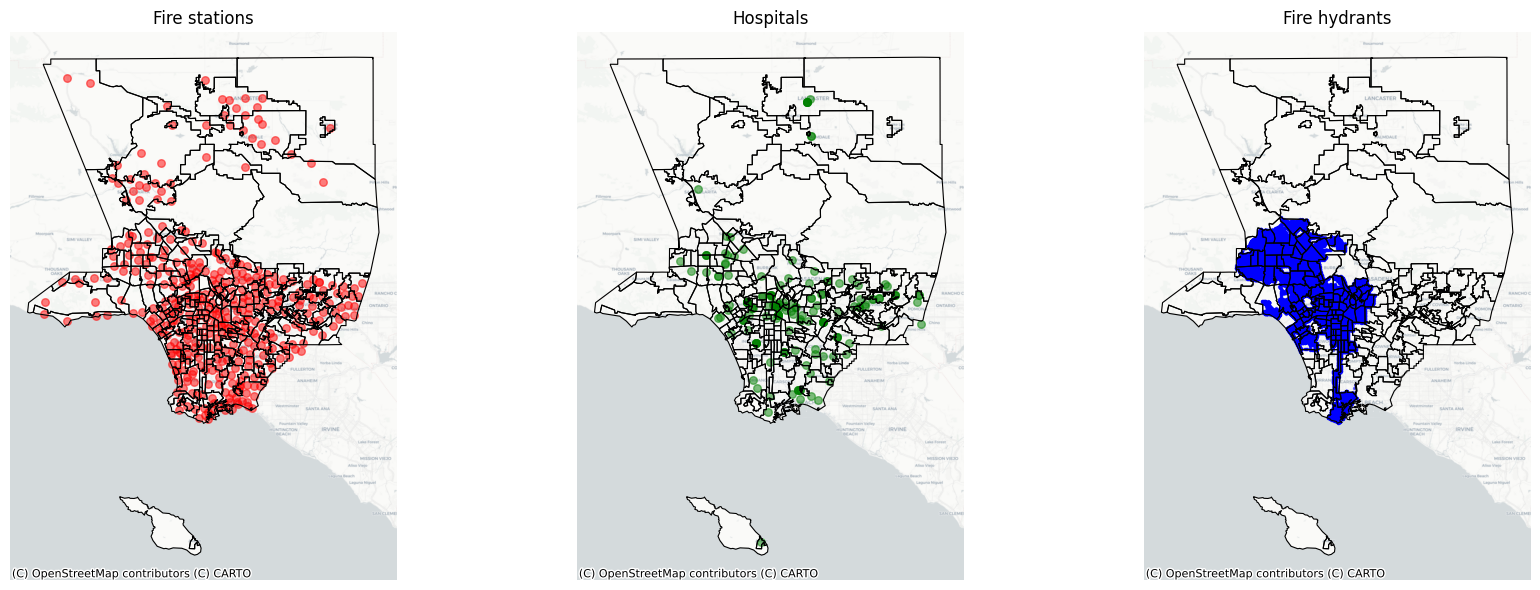

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ["Fire stations", "Hospitals", "Fire hydrants"]
layers_subset = [stations, hospitals, hydrants]
colors = ["red", "green", "blue"]
sizes = [30, 30, 2]

for ax, gdf, title, color, size in zip(axes, layers_subset, titles, colors, sizes):
    la_county.boundary.plot(ax=ax, color="black", linewidth=0.8)
    gdf.plot(ax=ax, color=color, markersize=size, alpha=0.5)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()